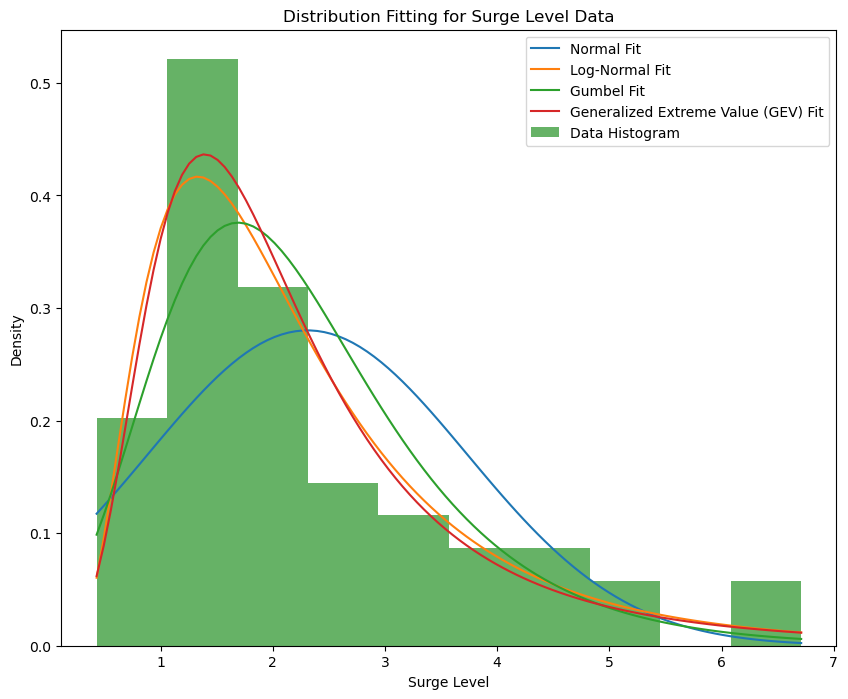

{'Normal': (2.3094545454545456, 1.4241685525652161),
 'Log-Normal': (0.6169349720670194, 0.04844557371782188, 1.8770049918911955),
 'Gumbel': (1.6908088850769478, 0.9788366548693673),
 'Generalized Extreme Value (GEV)': (-0.23964330093022207,
  1.5732428700432646,
  0.8655455466693214)}

In [12]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Provided surge data
data = np.array([
    6.1, 1.37, 3.05, 2.13, 1.83, 0.43, 4.72, 2.8, 4.88, 2.13, 2.13, 1.52, 3.96, 1.22, 2.13, 3.35, 4.48, 2.13, 
    1.22, 4.57, 1.22, 3.47, 1.37, 1.22, 0.88, 2.41, 0.91, 1.07, 6.71, 1.22, 3.47, 0.61, 1.83, 0.76, 1.98, 1.14, 
    1.68, 1.37, 0.99, 3.66, 3.85, 2.13, 2.13, 1.37, 2.44, 1.5, 2.13, 2.79, 1.52, 1.48, 5.33, 1.62, 1.28, 0.77, 2.56
])

# Distributions to fit
distributions = {
    'Normal': stats.norm,
    'Log-Normal': stats.lognorm,
    'Gumbel': stats.gumbel_r,
    'Generalized Extreme Value (GEV)': stats.genextreme
}

# Fit distributions and plot
plt.figure(figsize=(10, 8))
x = np.linspace(min(data), max(data), 100)

for name, distribution in distributions.items():
    params = distribution.fit(data)
    pdf = distribution.pdf(x, *params[:-2], loc=params[-2], scale=params[-1])
    
    plt.plot(x, pdf, label=f'{name} Fit')
    
plt.hist(data, bins=10, density=True, alpha=0.6, color='g', label='Data Histogram')
plt.xlabel('Surge Level')
plt.ylabel('Density')
plt.title('Distribution Fitting for Surge Level Data')
plt.legend()
plt.show()

# Print the fitted parameters
fitted_params = {name: distribution.fit(data) for name, distribution in distributions.items()}
fitted_params


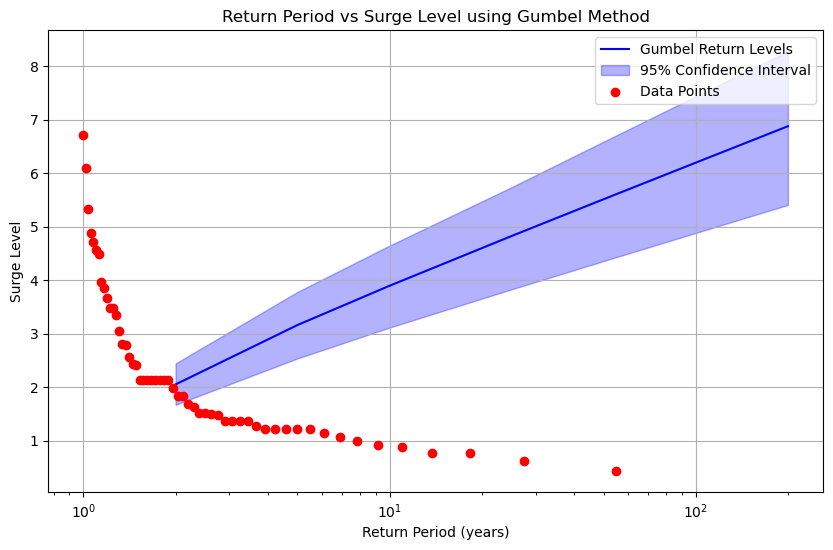

In [22]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Provided surge data
data = np.array([
    6.1, 1.37, 3.05, 2.13, 1.83, 0.43, 4.72, 2.8, 4.88, 2.13, 2.13, 1.52, 3.96, 1.22, 2.13, 3.35, 4.48, 2.13, 
    1.22, 4.57, 1.22, 3.47, 1.37, 1.22, 0.88, 2.41, 0.91, 1.07, 6.71, 1.22, 3.47, 0.61, 1.83, 0.76, 1.98, 1.14, 
    1.68, 1.37, 0.99, 3.66, 3.85, 2.13, 2.13, 1.37, 2.44, 1.5, 2.13, 2.79, 1.52, 1.48, 5.33, 1.62, 1.28, 0.77, 2.56
])

# Fit data to the Gumbel distribution
gumbel_params = stats.gumbel_r.fit(data)
loc, scale = gumbel_params

# Define return periods
return_periods = np.array([2, 5, 10, 25, 50, 100, 200])
probabilities = 1 - 1 / return_periods

# Calculate return levels
return_levels = stats.gumbel_r.ppf(probabilities, loc=loc, scale=scale)

# Calculate the 95% confidence intervals using the bootstrap method
n_bootstrap = 200
bootstrap_return_levels = np.zeros((n_bootstrap, len(return_periods)))

for i in range(n_bootstrap):
    resample_data = np.random.choice(data, size=len(data), replace=True)
    resample_params = stats.gumbel_r.fit(resample_data)
    bootstrap_return_levels[i, :] = stats.gumbel_r.ppf(probabilities, *resample_params)

lower_confidence = np.percentile(bootstrap_return_levels, 2.5, axis=0)
upper_confidence = np.percentile(bootstrap_return_levels, 97.5, axis=0)

# Calculate empirical return periods for the actual data points
sorted_data = np.sort(data)
empirical_return_periods = len(data) / (np.arange(1, len(data) + 1))

# Plot the return period curve with confidence intervals and data markers
plt.figure(figsize=(10, 6))
plt.plot(return_periods, return_levels, 'b-', label='Gumbel Return Levels')
plt.fill_between(return_periods, lower_confidence, upper_confidence, color='blue', alpha=0.3, label='95% Confidence Interval')
plt.scatter(empirical_return_periods, sorted_data, color='red', label='Data Points', zorder=5)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel('Return Period (years)')
plt.ylabel('Surge Level')
plt.title('Return Period vs Surge Level using Gumbel Method')
plt.legend()
plt.grid(True)
plt.show()
